# Linear Regression using Gradient Descent
Question: Given depth  how well can i predict temperature  using **linear regression** via **gradient descent**?

Note: Of course temp isn't only a factor of depth, since it also depends on seasons significantly, as well as longitude somewhat. A multivariable gradient descent will of course be more accurate, however I'm beginning with a single variable and will later move on to more advanced models.
   

In [7]:
import math, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Loading and Visualizing Dataset

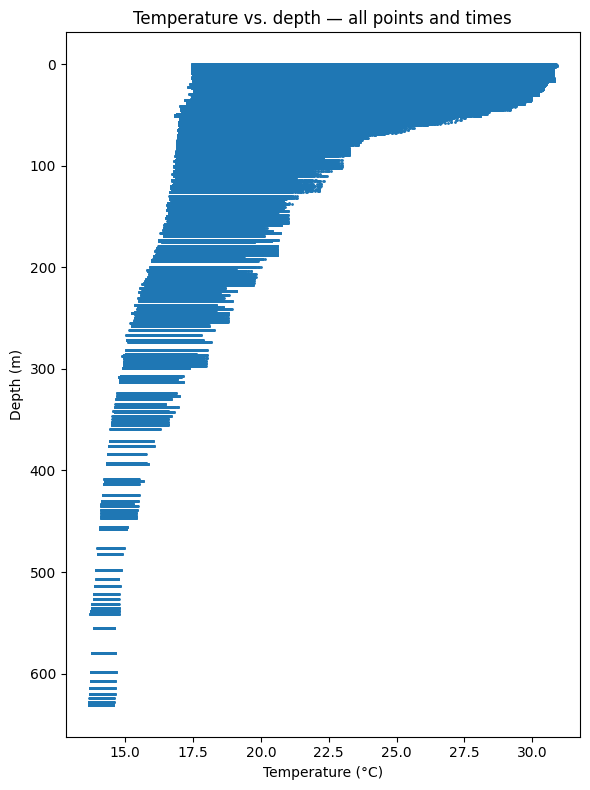

In [9]:
raw = pd.read_csv("C:/Users/IMG/Documents/ocean-timeseries-ml/data/raw/xsec_south", sep=r"\s+", header=None).values  # [nz*nx*nt, 6]

depth_all = raw[:, 1]    # every depth value, flat
temp_all  = raw[:, 2]    # every temperature value, flat

plt.figure(figsize=(6, 8))
plt.scatter(temp_all, depth_all, s=1)   # small, transparent points
plt.gca().invert_yaxis()                            # surface at top
plt.xlabel("Temperature (°C)")
plt.ylabel("Depth (m)")
plt.title("Temperature vs. depth — all points and times")
plt.tight_layout()
plt.show()

# Find Paramaters of linear regression using functions from ML course
 

| Depth (m)     | Temp (°C) |
| ----------------| ------------------------ |
| x               | y                      |


In [68]:
x_train = depth_all[1:10000]  # features
y_train  = temp_all [1:10000]   # target value

#Function to calculate the cost
def compute_cost(x, y, w, b):
   
    m = x.shape[0] 
    cost = 0
    
    for i in range(m):
        f_wb = w * x[i] + b
        cost = cost + (f_wb - y[i])**2
    total_cost = 1 / (2 * m) * cost

    return total_cost

def compute_gradient(x, y, w, b): 
    """
    Computes the gradient for linear regression 
    Args:
      x (ndarray (m,)): Data, m examples 
      y (ndarray (m,)): target values
      w,b (scalar)    : model parameters  
    Returns
      dj_dw (scalar): The gradient of the cost w.r.t. the parameters w
      dj_db (scalar): The gradient of the cost w.r.t. the parameter b     
     """
    
    # Number of training examples
    m = x.shape[0]    
    dj_dw = 0
    dj_db = 0
    
    for i in range(m):  
        f_wb = w * x[i] + b 
        dj_dw_i = (f_wb - y[i]) * x[i] 
        dj_db_i = f_wb - y[i] 
        dj_db += dj_db_i
        dj_dw += dj_dw_i 
    dj_dw = dj_dw / m 
    dj_db = dj_db / m 
        
    return dj_dw, dj_db

def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function): 
    """
    Performs gradient descent to fit w,b. Updates w,b by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      x (ndarray (m,))  : Data, m examples 
      y (ndarray (m,))  : target values
      w_in,b_in (scalar): initial values of model parameters  
      alpha (float):     Learning rate
      num_iters (int):   number of iterations to run gradient descent
      cost_function:     function to call to produce cost
      gradient_function: function to call to produce gradient
      
    Returns:
      w (scalar): Updated value of parameter after running gradient descent
      b (scalar): Updated value of parameter after running gradient descent
      J_history (List): History of cost values
      p_history (list): History of parameters [w,b] 
      """
    
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    p_history = []
    b = b_in
    w = w_in
    
    for i in range(num_iters):
        # Calculate the gradient and update the parameters using gradient_function
        dj_dw, dj_db = gradient_function(x, y, w , b)     

        # Update Parameters using equation (3) above
        b = b - alpha * dj_db                            
        w = w - alpha * dj_dw                            

        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            J_history.append( cost_function(x, y, w , b))
            p_history.append([w,b])
        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                  f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                  f"w: {w: 0.3e}, b:{b: 0.5e}")
 
    return w, b, J_history, p_history #return w and J,w history for graphing

# initialize parameters
w_init = -5
b_init = 20
# some gradient descent settings
iterations = 1000
tmp_alpha = 1.0e-5
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha, 
                                                    iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration    0: Cost 1.65e+05  dj_dw: -1.075e+05, dj_db: -4.069e+02   w: -3.925e+00, b: 2.00041e+01
Iteration  100: Cost 4.98e-01  dj_dw:  2.667e-03, dj_db: -7.064e-01   w: -9.923e-03, b: 2.00196e+01
Iteration  200: Cost 4.97e-01  dj_dw:  2.668e-03, dj_db: -7.059e-01   w: -9.926e-03, b: 2.00203e+01
Iteration  300: Cost 4.97e-01  dj_dw:  2.666e-03, dj_db: -7.054e-01   w: -9.929e-03, b: 2.00210e+01
Iteration  400: Cost 4.96e-01  dj_dw:  2.665e-03, dj_db: -7.049e-01   w: -9.931e-03, b: 2.00217e+01
Iteration  500: Cost 4.96e-01  dj_dw:  2.663e-03, dj_db: -7.044e-01   w: -9.934e-03, b: 2.00224e+01
Iteration  600: Cost 4.95e-01  dj_dw:  2.661e-03, dj_db: -7.040e-01   w: -9.937e-03, b: 2.00231e+01
Iteration  700: Cost 4.95e-01  dj_dw:  2.659e-03, dj_db: -7.035e-01   w: -9.939e-03, b: 2.00238e+01
Iteration  800: Cost 4.94e-01  dj_dw:  2.657e-03, dj_db: -7.030e-01   w: -9.942e-03, b: 2.00245e+01
Iteration  900: Cost 4.94e-01  dj_dw:  2.655e-03, dj_db: -7.025e-01   w: -9.945e-03, b: 2.00252e+01


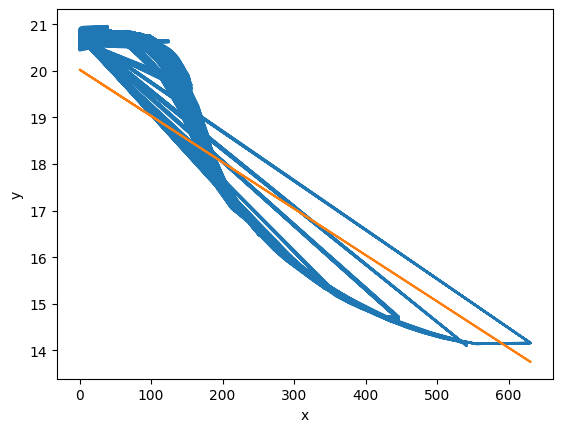

In [69]:
y_hat= w_final * x_train + b_final
plt.plot(x_train,y_train)
plt.plot(x_train, y_hat)
plt.xlabel("x")
plt.ylabel("y")
plt.show()